# Canopy simulation

In this tutorial, we introduce the canopy simulation capabilities of Eradiate. We will explore the features and interfaces of different objects used to construct a scene, simulate radiative transfer and visualise results.

In [1]:
# We import general processing and plotting libraries
import numpy as np
import matplotlib.pyplot as plt

# We import the top-level Eradiate module
import eradiate

# We load Eradiate's IPython extension for improved object inspection
%load_ext eradiate

# We set the Matplotlib inline backend to SVG for better figure quality
%matplotlib inline
%config InlineBackend.figure_formats = ["svg"]

# For convenience, we alias a few components
from eradiate import unit_registry as ureg
import eradiate.scenes as ertsc
import eradiate.experiments as ertxp

# We'll use the monochromatic mode in double precision
eradiate.set_mode("mono_double")

# We activate a few convenient presets
eradiate.plot.set_style(rc={"figure.dpi": 96})

jit_cuda_init(): cuInit failed, disabling CUDA backend.
There are two common explanations for this type of failure:

 1. your computer simply does not contain a graphics card that supports CUDA.

 2. your CUDA kernel module and CUDA library are out of sync. Try to see if you
    can run a utility like 'nvida-smi'. If not, a reboot will likely fix this
    issue. Otherwise reinstall your graphics driver.

 The specific error message produced by cuInit was
   "no CUDA-capable device is detected"


We start with the definition of a couple of utility functions which will simplify result visualisation.

In [2]:
def show_camera(
    exp,
    measure_id,
    robust=True,
    add_colorbar=False,
    vmin=None,
    vmax=None,
):
    """
    Display the output of a monochromatic camera measure.
    """
    _, ax = plt.subplots(1,1)
    exp.results[measure_id]["radiance"].squeeze(drop=True).plot.imshow(
        ax=ax,
        origin="upper",
        cmap="Greys_r",
        vmin=vmin,
        vmax=vmax,
        robust=robust,
        add_colorbar=add_colorbar,
    )
    ax.set_aspect(1)
    plt.show()
    plt.close()

def show_brf(exp, measure_id):
    """
    Display the BRF output of a distant radiance measure.
    """
    _, ax = plt.subplots(1,1)
    with plt.style.context({"lines.linestyle": ":", "lines.marker": "."}):
        exp.results[measure_id]["brf"].squeeze(drop=True).plot(ax=ax, x="vza")
    plt.show()
    plt.close()

## Rendering a surface

First, let's create a very simple scene consisting of a default Lambertian surface observed by a camera. We start by defining the surface and set its width to 10 m (the default is much larger).

In [3]:
lambertian_surface=ertsc.surface.BasicSurface(
    shape=ertsc.shapes.RectangleShape(edges=10.0 * ureg.m),
    bsdf=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
)
lambertian_surface

BasicSurface(
    id='surface',
    shape=RectangleShape(
        id='shape',
        bsdf=None,
        edges=[10.0 10.0] m,
        center=[0 0 0] m,
        normal=array([0., 0., 1.]),
        up=array([0., 1., 0.])
    ),
    bsdf=LambertianBSDF(
        id='bsdf',
        reflectance=UniformSpectrum(id=None, quantity=REFLECTANCE, value=0.5)
    )
)

Now, let's make a monochromatic render of this scene. We'll produce a 4:3 ratio image with a fairly low resolution sample count—all we want is to visualise the scene.

**Note**: Using the correlated *k* band mode to render scenes is more computationally intensive. Therefore, we will stick to Eradiate's monochromatic mode for renders in this tutorial.

In [4]:
camera_oblique = ertsc.measure.PerspectiveCameraMeasure(
    id="camera_oblique",
    origin=[15, 15, 15] * ureg.m,
    target=[0, 0, 0] * ureg.m,
    up=[0, 0, 1],
    film_resolution=(320, 240),
    spp=512,
)
exp = ertxp.RamiExperiment(
    surface=lambertian_surface,
    measures=camera_oblique,
)
exp

RamiExperiment(
    measures=[
        PerspectiveCameraMeasure(
            flags=<MeasureFlags.0: 0>,
            id='camera_oblique',
            results={},
            spectral_cfg=MonoMeasureSpectralConfig(
                srf=UniformSpectrum(id=None, quantity=DIMENSIONLESS, value=1.0),
                _wavelengths=[550.0] nm
            ),
            split_spp=None,
            spp=512,
            _film_resolution=(320, 240),
            origin=[15 15 15] m,
            target=[0 0 0] m,
            up=array([0, 0, 1]),
            far_clip=10000.0 km,
            fov=50.0 deg
        )
    ],
    illumination=DirectionalIllumination(
        id='illumination',
        zenith=0.0 deg,
        azimuth=0.0 deg,
        irradiance=SolarIrradianceSpectrum(
            id=None,
            dataset=<xarray.Dataset>
Dimensions:  (w: 2198, t: 0)
Coordinates:
  * w        (w) float64 200.0 201.0 202.0 ... 2.395e+03 2.396e+03 2.397e+03
  * t        (t) float64 
Data variables:
    ssi      (w) float64 ...
Attributes:
    convention:  CF-1.8
    title:       Thuillier (2003) solar irradiance spectrum
    history:     2020-12-15 11:50:46 - data set creation - eradiate-datasets_...
    source:      Combined observations from the SOLSPEC instrument during the...
    references:  https://doi.org/10.1023/A:1024048429145
    obs_start:   1992-03-24
    obs_end:     1993-07-01
    url:         original data available at https://oceancolor.gsfc.nasa.gov/...,
            scale=1.0,
            datetime=None
        )
    ),
    canopy=None,
    padding=0,
    surface=BasicSurface(
        id='surface',
        shape=RectangleShape(
            id='shape',
            bsdf=None,
            edges=[10.0 10.0] m,
            center=[0 0 0] m,
            normal=array([0., 0., 1.]),
            up=array([0., 1., 0.])
        ),
        bsdf=LambertianBSDF(
            id='bsdf',
            reflectance=UniformSpectrum(
                id=None,
                quantity=REFLECTANCE,
                value=0.5
            )
        )
    ),
    _integrator=PathIntegrator(
        id='integrator',
        max_depth=None,
        rr_depth=None,
        hide_emitters=None
    )
)

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

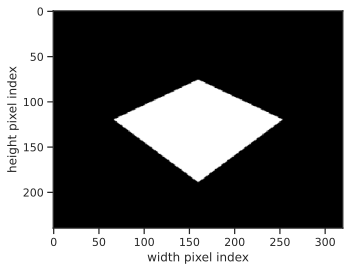

In [5]:
eradiate.run(exp)
show_camera(exp, "camera_oblique")

You might notice some rendering artefacts. This is because Eradiate's camera settings are currently not optimised for rendering. This will be improved in future releases.

## Rendering a surface and canopy


Let's add a canopy above this ground patch. We'll configure a homogeneous canopy composed of randomly oriented floating disks. This is done using the [DiscreteCanopy](../rst/reference_api/generated/autosummary/eradiate.scenes.biosphere.DiscreteCanopy.rst) class, or, rather, its [homogeneous()](../rst/reference_api/generated/autosummary/eradiate.scenes.biosphere.DiscreteCanopy.rst#eradiate.scenes.biosphere.DiscreteCanopy.homogeneous) class constructor. We will use abstract parameters for the sake of demonstrating this feature:

In [6]:
homogeneous_canopy = ertsc.biosphere.DiscreteCanopy.homogeneous(
    l_vertical=1.0 * ureg.m,
    l_horizontal=10.0 * ureg.m,
    lai=2.0,
    leaf_radius=10 * ureg.cm,
)

We add this canopy to a scene with a surface using the [RamiExperiment](../rst/reference_api/generated/autosummary/eradiate.experiments.RamiExperiment.rst) class. Note that this time, we don't set the surface size: it is automatically adjusted to match the extents we set for the canopy object.

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

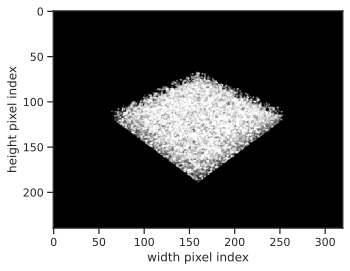

In [7]:
exp = ertxp.RamiExperiment(
    surface=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
    canopy=homogeneous_canopy,
    measures=camera_oblique,
)
eradiate.run(exp)
show_camera(exp, "camera_oblique")


## Rendering a surface and padded canopy


In order to simulate the fact that our canopy is periodic, we can pad it with clones of itself. Let's start with just of few of them.

**Tip**: If the render time is too long, you can reduce the number of radiance samples per image pixel by adjusting the measure's `spp` parameter.


Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

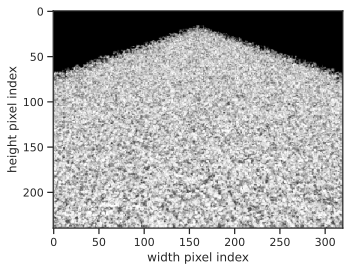

In [8]:
camera_oblique = ertsc.measure.PerspectiveCameraMeasure(
    id="camera_oblique",
    origin=[15, 15, 15] * ureg.m,
    target=[0, 0, 0],
    up=[0, 0, 1],
    film_resolution=(320, 240),
    spp=64,  # Lower sample count value ensures quicker rendering
)

exp = ertxp.RamiExperiment(
    surface=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
    canopy=homogeneous_canopy,
    padding=1,
    measures=camera_oblique,
)
eradiate.run(exp)
show_camera(exp, "camera_oblique")

Now, let's relocate our camera to the top of canopy. We will observe it at a grazing angle.

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

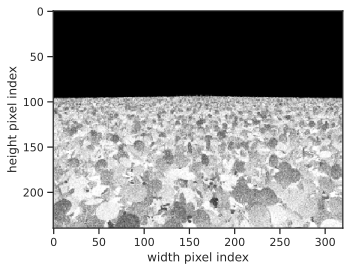

In [9]:
camera_toc = ertsc.measure.PerspectiveCameraMeasure(
    id="camera_toc",
    origin=[15, 15, 2] * ureg.m,
    target=[0, 0, 0],
    up=[0, 0, 1],
    film_resolution=(320, 240),
    spp=64,  # Lower sample count value ensures quicker rendering
)
exp = ertxp.RamiExperiment(
    surface=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
    canopy=homogeneous_canopy,
    padding=2,
    measures=[camera_toc],
)
eradiate.run(exp)
show_camera(exp, "camera_toc")

## Computing the BRF in the principal plane

Now that we know how to build our scene, we are going to compute the BRF in the principal plane for a similar scene. This is similar to the test cases for which we can submit results to the RAMI online checker (ROMC.)

In order to observe something meaningful, let's set the Sun zenith angle to 30°.

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

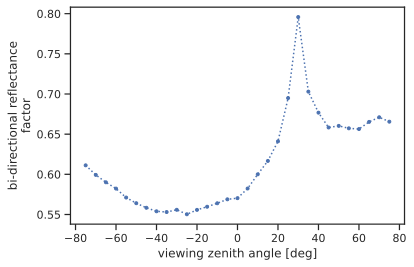

In [10]:
illumination = ertsc.illumination.DirectionalIllumination(
    zenith=30.0, azimuth=0.0
)

brf_pplane = ertsc.measure.MultiDistantMeasure.from_viewing_angles(
    id="brf_pplane",
    azimuths=0.0,
    zeniths=np.arange(-75, 76, 5),
    spp=50000,
)

exp = ertxp.RamiExperiment(
    illumination=illumination,
    surface=ertsc.bsdfs.LambertianBSDF(),
    canopy=homogeneous_canopy,
    padding=10,
    measures=[brf_pplane],
)
eradiate.run(exp)
show_brf(exp, "brf_pplane")

There still is some Monte Carlo noise, but we're keeping the number of samples low in order so that the simulation remains short.

**Exercises for the interested reader**

1. Change the viewing zenith angle and verify that the hot spot moves accordingly.
2. Change the viewing azimuth angle and adjust the measure so as to keep it aligned with the principal plane.
3. Compute the BRF in a plane orthgonal to the principal plane.
4. Gradually increase padding and determine from which value the quasi-periodic approximation can be considered valid.

## Computing the BRF in the principal plane with an atmosphere

Finally, we can combine our canopy with an atmosphere. This uses a different experiment class ([Rami4ATMExperiment](../rst/reference_api/generated/autosummary/eradiate.experiments.Rami4ATMExperiment.rst)), which merges the capabilities of the `RamiExperiment` and `OneDimExperiment` classes. We will only use a purely scattering atmosphere and perform monochromatic simulations so as to limit the runtime of our examples.

In [11]:
eradiate.set_mode("mono_double")

We will first add a default atmosphere and reuse the top-of-canopy view from our earlier example.

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

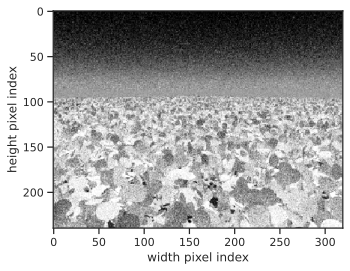

In [12]:
camera_toc = ertsc.measure.PerspectiveCameraMeasure(
    id="camera_toc",
    origin=[15, 15, 2] * ureg.m,
    target=[0, 0, 0],
    up=[0, 0, 1],
    film_resolution=(320, 240),
    spp=64,  # Lower sample count value ensures quicker rendering
)
exp = ertxp.Rami4ATMExperiment(
    surface=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
    atmosphere=ertsc.atmosphere.MolecularAtmosphere(has_absorption=False),
    canopy=homogeneous_canopy,
    padding=2,
    measures=[camera_toc],
)
eradiate.run(exp)
show_camera(exp, "camera_toc")

Our render is very noisy, but we can clearly see that the addition of the atmosphere to our previous setup added a haze. We can now reposition our camera to the ToA and select a wavelength in the UV, where Rayleigh scattering is strong:

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 2 Axes>

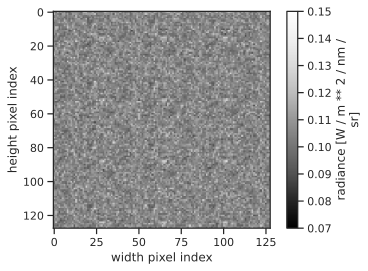

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 2 Axes>

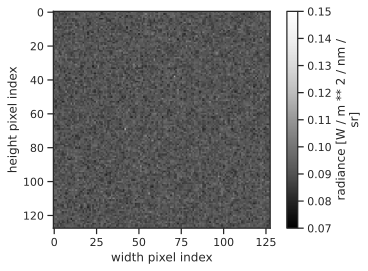

In [13]:
for atmosphere in [
    None,  # Atmosphere-free reference
    ertsc.atmosphere.MolecularAtmosphere(has_absorption=False)  # Rayleigh scattering only (no gaseous absorption, no aerosols)
]:
    camera_toa = ertsc.measure.PerspectiveCameraMeasure(
        id="camera_toa",
        origin=[0, 0, 101] * ureg.km,
        target=[0, 0, 0],
        up=[0, 1, 0],
        film_resolution=(128, 128),
        fov=2e-2,  # The camera is far away, reducing the field of view is like zooming
        spp=512,  # Lower sample count value ensures quicker rendering
        spectral_cfg={"wavelengths": [300.0] * ureg.nm},
    )
    exp = ertxp.Rami4ATMExperiment(
        surface=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
        atmosphere=atmosphere,
        canopy=homogeneous_canopy,
        padding=2,
        measures=[camera_toa],
    )
    eradiate.run(exp)
    show_camera(exp, "camera_toa", add_colorbar=True, vmin=0.07, vmax=0.15)
    # Note: Normalise v-range so that we can compare both images

Despite the noise, we can see that Rayleigh scattering dims the signal at this wavelength.

**Exercises for the interested reader**

1. With a non-zenith illumination, set up a TOA BRF measurement for a few wavelengths ranging from the UV to NIR regions and see how Rayleigh scattering broadens the hot spot reflective lobe.
1. Increase padding value and see how adjacency effects impact simulation results differently depending on the wavelength.
2. Switch to the CKD mode and compute the TOA BRF for Sentinel-2 bands 1 and 8A. You will have to use the AFGL 1986 atmosphere model. You will also have to adust simulation parameters to keep the computational time reasonable while setting up your simulation (decrease the sample count while preparing it, then increase it to compute the final results).

0/6|          | 00:00, ETA=?

Mitsuba:   0%|          | 00:00, ETA=?

Mitsuba:   0%|          | 00:00, ETA=?

Mitsuba:   0%|          | 00:00, ETA=?

Mitsuba:   0%|          | 00:00, ETA=?

Mitsuba:   0%|          | 00:00, ETA=?

Mitsuba:   0%|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

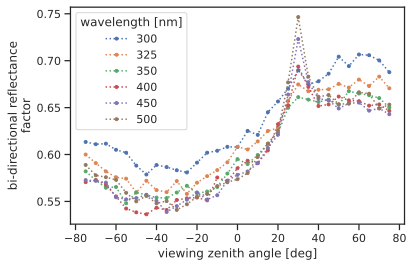

In [14]:
# Solution to exercise 1

toa_brf = ertsc.measure.MultiDistantMeasure.from_viewing_angles(
    id="toa_brf",
    zeniths=np.arange(-75, 76, 5),
    azimuths=0.0,
    spp=10000,
    spectral_cfg={"wavelengths": [300, 325, 350, 400, 450, 500]}
)

exp = ertxp.Rami4ATMExperiment(
    illumination=ertsc.illumination.DirectionalIllumination(zenith=30.0),
    surface=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
    atmosphere=ertsc.atmosphere.MolecularAtmosphere(has_absorption=False),
    canopy=homogeneous_canopy,
    padding=2,
    measures=[toa_brf],
)
eradiate.run(exp)
ds = exp.results["toa_brf"]

with plt.style.context({"lines.linestyle": ":", "lines.marker": "."}):
    ds.brf.squeeze(drop=True).plot(hue="w", x="vza")
plt.show()
plt.close()

0/80|          | 00:00, ETA=?

<Figure size 576x384 with 1 Axes>

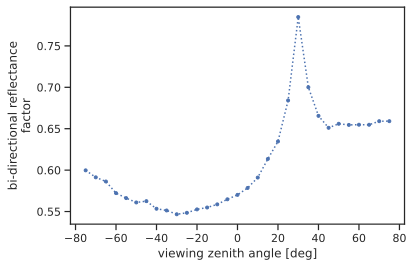

In [15]:
# Solution to exercise 3

eradiate.set_mode("ckd_double")
eradiate.config.progress = 1  # Do not show Mitsuba-level progress bar

toa_brf = ertsc.measure.MultiDistantMeasure.from_viewing_angles(
    id="toa_brf",
    zeniths=np.arange(-75, 76, 5),
    azimuths=0.0,
    spp=1000,
    spectral_cfg={"srf": "sentinel_2a-msi-8a"}
)

exp = ertxp.Rami4ATMExperiment(
    illumination=ertsc.illumination.DirectionalIllumination(zenith=30.0),
    surface=ertsc.bsdfs.LambertianBSDF(reflectance=0.5),
    atmosphere=ertsc.atmosphere.MolecularAtmosphere.afgl_1986(),
    canopy=homogeneous_canopy,
    padding=2,
    measures=[toa_brf],
)
eradiate.run(exp)
ds = exp.results["toa_brf"]

with plt.style.context({"lines.linestyle": ":", "lines.marker": "."}):
    ds.brf_srf.squeeze(drop=True).plot(x="vza")
plt.show()
plt.close()